In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
raw_data_filepath = "data/raw"

### 1. Import raw data

In [36]:
app_usage = pd.read_csv(raw_data_filepath+"/customusage_202511051357.csv")
event_info = pd.read_csv(raw_data_filepath+"/eventinfo_202511051356.csv")
event_type = pd.read_csv(raw_data_filepath+"/eventtype_202511051747.csv")
network_usage = pd.read_csv(raw_data_filepath+"/networkusage_202511051357.csv")

### 2. Data inspection

In [44]:
app_usage.dtypes

id                        int64
userId                   object
packageName              object
firstTimeStamp           object
lastTimeStamp            object
lastTimeUsed             object
totalTimeInForeground     int64
dtype: object

In [41]:
app_usage.head(1)

,id,userId,packageName,firstTimeStamp,lastTimeStamp,lastTimeUsed,totalTimeInForeground
0,1,058d7a55-ad66-4e96-9281-8aed319bfd5b,com.google.android.youtube,2025-10-15 03:05:26.129,2025-10-16 03:05:26.128,2025-10-15 03:55:14.779,303251


In [45]:
event_info.dtypes

id              int64
userId         object
packageName    object
eventType       int64
eventDate      object
className      object
dtype: object

In [40]:
event_info.head(1)

,id,userId,packageName,eventType,eventDate,className
0,1,058d7a55-ad66-4e96-9281-8aed319bfd5b,android,18,2025-10-16 04:26:29.885,NaN


In [46]:
event_type.dtypes

id              int64
eventType       int64
eventValue     object
description    object
dtype: object

In [42]:
event_type.head(1)

,id,eventType,eventValue,description
0,1,1,ACTIVITY_RESUMED,An event type denoting that an Activity moved ...


In [47]:
network_usage.dtypes

id                        int64
userId                   object
packageName              object
totalReceivedBytes        int64
totalTransferredBytes     int64
startDate                object
endDate                  object
dtype: object

In [43]:
network_usage.head(1)

,id,userId,packageName,totalReceivedBytes,totalTransferredBytes,startDate,endDate
0,8760,058d7a55-ad66-4e96-9281-8aed319bfd5b,com.shazam.android,12571,12307,2025-10-16 00:01:00.000,2025-10-16 14:29:20.812


### 3. Parsing dtypes

In [48]:
#to_datetime
##app_usage
app_usage.firstTimeStamp = pd.to_datetime(app_usage.firstTimeStamp)
app_usage.lastTimeStamp = pd.to_datetime(app_usage.lastTimeStamp)
app_usage.lastTimeUsed = pd.to_datetime(app_usage.lastTimeUsed)

##event_info
event_info.eventDate = pd.to_datetime(event_info.eventDate)

##network_usage
network_usage.startDate = pd.to_datetime(network_usage.startDate)
network_usage.endDate = pd.to_datetime(network_usage.endDate)



In [49]:
app_usage.dtypes

id                                int64
userId                           object
packageName                      object
firstTimeStamp           datetime64[ns]
lastTimeStamp            datetime64[ns]
lastTimeUsed             datetime64[ns]
totalTimeInForeground             int64
dtype: object

In [50]:
event_info.dtypes

id                      int64
userId                 object
packageName            object
eventType               int64
eventDate      datetime64[ns]
className              object
dtype: object

In [51]:
network_usage.dtypes

id                                int64
userId                           object
packageName                      object
totalReceivedBytes                int64
totalTransferredBytes             int64
startDate                datetime64[ns]
endDate                  datetime64[ns]
dtype: object

### 4. Feature Engineering

In [52]:
app_usage["date"] = app_usage["firstTimeStamp"].dt.date

#### a. Daily screen

In [61]:
daily_screen = app_usage.groupby(["userId", "date"])["totalTimeInForeground"].sum().reset_index()
daily_screen["screen_time (minute)"] = daily_screen["totalTimeInForeground"] / 60000.0
daily_screen.drop(columns="totalTimeInForeground", inplace=True)

In [69]:
daily_screen.head(1)

,userId,date,screen_time (minute)
0,058d7a55-ad66-4e96-9281-8aed319bfd5b,2025-10-15,574.510983


#### a.a Apps category

In [105]:
app_categories = {
    "com.whatsapp": "social",
    "com.facebook.orca": "social",
    "com.facebook.katana": "social",
    "com.discord": "social",
    "org.chromium.webapk.*": "social",
    "com.twitter.android": "social",
    "com.instagram.android": "social",
    "com.google.android.youtube": "entertainment",
    "com.netflix.mediaclient": "entertainment",
    "com.spotify.music": "entertainment",
    "com.brave.browser": "entertainment",
    "com.android.chrome": "entertainment",
    "com.microsoft.office.outlook": "productivity",
    "com.google.android.apps.docs": "productivity",
    "com.miui.notes": "productivity",
    "com.datacamp": "productivity",
    "com.duolingo": "productivity",
}

app_usage["appCategory"] = app_usage["packageName"].map(app_categories).fillna("other")
screen_time_by_cat = app_usage.groupby(['userId','date','appCategory'])['totalTimeInForeground'].sum().reset_index()


In [107]:
screen_time_by_cat.head()

,userId,date,appCategory,totalTimeInForeground
0,058d7a55-ad66-4e96-9281-8aed319bfd5b,2025-10-15,entertainment,5168500
1,058d7a55-ad66-4e96-9281-8aed319bfd5b,2025-10-15,other,26094097
2,058d7a55-ad66-4e96-9281-8aed319bfd5b,2025-10-15,productivity,1507699
3,058d7a55-ad66-4e96-9281-8aed319bfd5b,2025-10-15,social,1700363
4,058d7a55-ad66-4e96-9281-8aed319bfd5b,2025-10-16,entertainment,19187466


#### b. Unlocks

In [116]:
event_info['eventDate'] = pd.to_datetime(event_info['eventDate'], utc=True).dt.tz_convert('Europe/Brussels')
event_info['date'] = event_info['eventDate'].dt.date
unlocks = event_info[event_info["eventType"]==18]\
    .groupby(["userId", "date"])\
    .size()\
    .reset_index(name="unlocks")
unlocks.head(1)

,userId,date,unlocks
0,058d7a55-ad66-4e96-9281-8aed319bfd5b,2025-10-16,80


#### c. Sessions (ACTIVITY_PAUSED->ACTIVITY_RESUMED)

In [117]:
pairs = event_info[event_info["eventType"].isin([1,2])].copy()
pairs = pairs.sort_values(["userId", "eventDate"])

pairs["nextEventType"] = pairs.groupby("userId")["eventType"].shift(-1)
pairs["nextEventDate"] = pairs.groupby("userId")["eventDate"].shift(-1)

pairs["nextEventType"] = pairs["nextEventType"].fillna(0.0).astype(int)

sessions = pairs[(pairs["eventType"]==1) & (pairs["nextEventType"]==2)].copy()
sessions["session_duration (minute)"] = (sessions["nextEventDate"] - sessions["eventDate"])\
    .dt.total_seconds()/60.0
sessions["date"] = sessions["eventDate"].dt.date

In [118]:
pairs.head(1)

,id,userId,packageName,eventType,eventDate,className,date,nextEventType,nextEventDate
795,794,058d7a55-ad66-4e96-9281-8aed319bfd5b,com.android.settings,1,2025-10-16 02:08:13.622000+02:00,com.android.settings.SubSettings,2025-10-16,2,2025-10-16 02:08:14.300000+02:00


In [119]:
sessions.head(1)

,id,userId,packageName,eventType,eventDate,className,date,nextEventType,nextEventDate,session_duration (minute)
795,794,058d7a55-ad66-4e96-9281-8aed319bfd5b,com.android.settings,1,2025-10-16 02:08:13.622000+02:00,com.android.settings.SubSettings,2025-10-16,2,2025-10-16 02:08:14.300000+02:00,0.0113


In [120]:
#filtrage session
sessions = sessions[(sessions["session_duration (minute)"]>=0) & (sessions["session_duration (minute)"]<=480)]

#### d. Micro sessions stats

In [121]:
session_stats = sessions\
    .groupby(["userId", "date"])["session_duration (minute)"]\
    .agg(total_sessions="count", short_sessions=lambda x: (x < 2.0)\
        .sum())\
    .reset_index()
session_stats["short_sessions_ratio"] = np\
    .where(session_stats["total_sessions"] > 0, session_stats["short_sessions"] / session_stats["total_sessions"], 0.0)
session_stats = session_stats[["userId", "date", "short_sessions_ratio"]]


In [122]:
session_stats.head(5)

,userId,date,short_sessions_ratio
0,058d7a55-ad66-4e96-9281-8aed319bfd5b,2025-10-16,0.933333
1,058d7a55-ad66-4e96-9281-8aed319bfd5b,2025-10-17,0.923664
2,27ceda13-79b4-44f0-82ce-9841391ae960,2025-10-17,0.902743
3,27ceda13-79b4-44f0-82ce-9841391ae960,2025-10-30,0.972393
4,27ceda13-79b4-44f0-82ce-9841391ae960,2025-10-31,0.977124


#### e. Night Usage

In [123]:
night = sessions.copy()
night_hour = night["eventDate"].dt.hour
night = night[(night_hour>=23) | (night_hour<6)]
night_usage = night.groupby(["userId", "date"])["session_duration (minute)"].sum().reset_index(name="night_minutes")

In [124]:
night_usage.head()

,userId,date,night_minutes
0,058d7a55-ad66-4e96-9281-8aed319bfd5b,2025-10-16,120.608733
1,058d7a55-ad66-4e96-9281-8aed319bfd5b,2025-10-17,110.937500
2,27ceda13-79b4-44f0-82ce-9841391ae960,2025-10-17,2.621750
3,27ceda13-79b4-44f0-82ce-9841391ae960,2025-10-30,0.115017
4,4af439ed-13c0-4a27-822c-2d30204aaa70,2025-10-17,4.079383


#### f. Network Usage

In [125]:
network_usage["date"] = network_usage["endDate"].dt.date
network_usage["totalBytes"] = network_usage["totalReceivedBytes"] + network_usage["totalTransferredBytes"]
network_daily = network_usage\
    .groupby(["userId", "date"])["totalBytes"]\
    .sum()\
    .reset_index(name="network_intensity")
network_daily.head()

,userId,date,network_intensity
0,058d7a55-ad66-4e96-9281-8aed319bfd5b,2025-10-16,861142624
1,058d7a55-ad66-4e96-9281-8aed319bfd5b,2025-10-17,14971146
2,27ceda13-79b4-44f0-82ce-9841391ae960,2025-10-17,636487094
3,27ceda13-79b4-44f0-82ce-9841391ae960,2025-10-30,326251590
4,27ceda13-79b4-44f0-82ce-9841391ae960,2025-10-31,352861144


#### g. Final dataset

In [126]:
unlocks

,userId,date,unlocks
0,058d7a55-ad66-4e96-9281-8aed319bfd5b,2025-10-16,80
1,058d7a55-ad66-4e96-9281-8aed319bfd5b,2025-10-17,8
2,27ceda13-79b4-44f0-82ce-9841391ae960,2025-10-17,64
3,27ceda13-79b4-44f0-82ce-9841391ae960,2025-10-30,63
4,27ceda13-79b4-44f0-82ce-9841391ae960,2025-10-31,71
...,...,...,...
67,fe495f55-be01-4917-b5b9-59352a1a3cd3,2025-10-30,24
68,fe495f55-be01-4917-b5b9-59352a1a3cd3,2025-10-31,1
69,fe495f55-be01-4917-b5b9-59352a1a3cd3,2025-11-02,26
70,fe495f55-be01-4917-b5b9-59352a1a3cd3,2025-11-03,26


In [131]:
final = daily_screen\
    .merge(unlocks, on=["userId", "date"], how="left")\
    .merge(session_stats, on=["userId", "date"], how="left")\
    .merge(night_usage, on=["userId", "date"], how="left")\
    .merge(network_daily, on=["userId", "date"], how="left")

final[['unlocks','short_sessions_ratio','night_minutes','network_intensity']] = \
    final[['unlocks','short_sessions_ratio','night_minutes','network_intensity']].fillna(0)

In [132]:
final

,userId,date,screen_time (minute),unlocks,short_sessions_ratio,night_minutes,network_intensity
0,058d7a55-ad66-4e96-9281-8aed319bfd5b,2025-10-15,574.510983,0.0,0.000000,0.000000,0.000000e+00
1,058d7a55-ad66-4e96-9281-8aed319bfd5b,2025-10-16,3228.520583,80.0,0.933333,120.608733,8.611426e+08
2,058d7a55-ad66-4e96-9281-8aed319bfd5b,2025-10-17,128.913400,8.0,0.923664,110.937500,1.497115e+07
3,27ceda13-79b4-44f0-82ce-9841391ae960,2025-10-16,516.287233,0.0,0.000000,0.000000,0.000000e+00
4,27ceda13-79b4-44f0-82ce-9841391ae960,2025-10-17,221.803017,64.0,0.902743,2.621750,6.364871e+08
...,...,...,...,...,...,...,...
75,fe495f55-be01-4917-b5b9-59352a1a3cd3,2025-10-29,130.390217,32.0,0.956522,1.630600,1.323864e+09
76,fe495f55-be01-4917-b5b9-59352a1a3cd3,2025-10-30,10.990533,24.0,0.951456,1.047883,9.350224e+08
77,fe495f55-be01-4917-b5b9-59352a1a3cd3,2025-11-01,147.246717,0.0,0.000000,0.000000,0.000000e+00
78,fe495f55-be01-4917-b5b9-59352a1a3cd3,2025-11-02,149.682850,26.0,0.954198,5.883100,7.812037e+08


In [ ]:
final['screen_norm']  = (final['screen_time_min'] / 240).clip(0,1)
final['unlocks_norm'] = (final['unlocks'] / 90).clip(0,1)
final['night_norm']   = (final['night_minutes'] / 30).clip(0,1)

final['risk_score'] = (0.35*final['screen_norm']
                     + 0.25*final['unlocks_norm']
                     + 0.25*final['night_norm']
                     + 0.15*final['short_sessions_ratio'])

final = final.sort_values(['userId','date'])
final.head()

,userId,date,screen_time (minute),unlocks,short_sessions_ratio,night_minutes,network_intensity,screen_norm,unlocks_norm,night_norm,risk_score
0,058d7a55-ad66-4e96-9281-8aed319bfd5b,2025-10-15,574.510983,0.0,0.000000,0.000000,0.0,1.000000,0.000000,0.000000,0.350000
1,058d7a55-ad66-4e96-9281-8aed319bfd5b,2025-10-16,3228.520583,80.0,0.933333,120.608733,861142624.0,1.000000,0.888889,1.000000,0.962222
2,058d7a55-ad66-4e96-9281-8aed319bfd5b,2025-10-17,128.913400,8.0,0.923664,110.937500,14971146.0,0.537139,0.088889,1.000000,0.598771
3,27ceda13-79b4-44f0-82ce-9841391ae960,2025-10-16,516.287233,0.0,0.000000,0.000000,0.0,1.000000,0.000000,0.000000,0.350000
4,27ceda13-79b4-44f0-82ce-9841391ae960,2025-10-17,221.803017,64.0,0.902743,2.621750,636487094.0,0.924179,0.711111,0.087392,0.658500


In [130]:
event_info.eventType.unique()

array([18, 11,  1, 15, 17, 23,  2, 16, 12, 20, 19, 10,  7, 27, 28,  5, 26,
        9, 14])

In [200]:
final = final[final["userId"]!="058d7a55-ad66-4e96-9281-8aed319bfd5b"].reset_index()

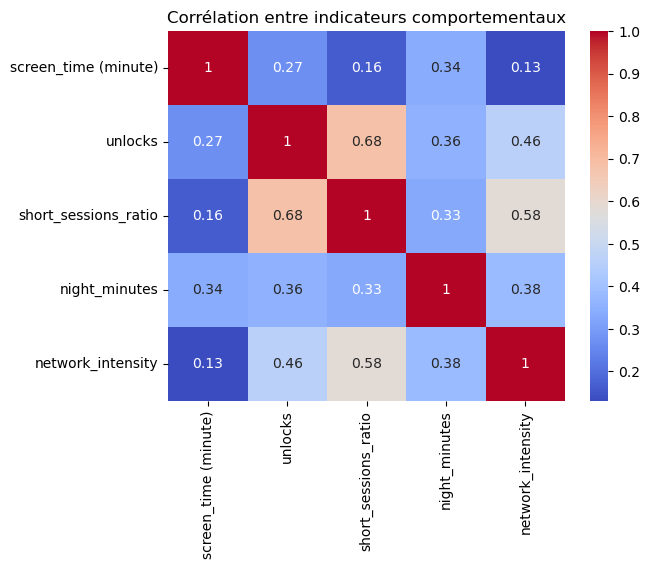

In [142]:
import seaborn as sns

corr = final[['screen_time (minute)','unlocks','short_sessions_ratio','night_minutes','network_intensity']].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Corrélation entre indicateurs comportementaux")
plt.show()


In [143]:
final.head()


,index,userId,date,screen_time (minute),unlocks,short_sessions_ratio,night_minutes,network_intensity,screen_norm,unlocks_norm,night_norm,risk_score
0,3,27ceda13-79b4-44f0-82ce-9841391ae960,2025-10-16,516.287233,0.0,0.000000,0.000000,0.0,1.000000,0.000000,0.000000,0.350000
1,4,27ceda13-79b4-44f0-82ce-9841391ae960,2025-10-17,221.803017,64.0,0.902743,2.621750,636487094.0,0.924179,0.711111,0.087392,0.658500
2,5,27ceda13-79b4-44f0-82ce-9841391ae960,2025-10-29,261.464567,0.0,0.000000,0.000000,0.0,1.000000,0.000000,0.000000,0.350000
3,6,27ceda13-79b4-44f0-82ce-9841391ae960,2025-10-30,498.067017,63.0,0.972393,0.115017,326251590.0,1.000000,0.700000,0.003834,0.671817
4,7,27ceda13-79b4-44f0-82ce-9841391ae960,2025-10-31,144.705067,71.0,0.977124,0.000000,352861144.0,0.602938,0.788889,0.000000,0.554819


## 2. CLustering

In [150]:
features = [
    "screen_norm",
    "unlocks_norm",
    "short_sessions_ratio",
    "night_norm",
]


In [151]:
final.columns

Index(['index', 'userId', 'date', 'screen_time (minute)', 'unlocks',
       'short_sessions_ratio', 'night_minutes', 'network_intensity',
       'screen_norm', 'unlocks_norm', 'night_norm', 'risk_score'],
      dtype='object')

In [152]:
final

,index,userId,date,screen_time (minute),unlocks,short_sessions_ratio,night_minutes,network_intensity,screen_norm,unlocks_norm,night_norm,risk_score
0,3,27ceda13-79b4-44f0-82ce-9841391ae960,2025-10-16,516.287233,0.0,0.000000,0.000000,0.000000e+00,1.000000,0.000000,0.000000,0.350000
1,4,27ceda13-79b4-44f0-82ce-9841391ae960,2025-10-17,221.803017,64.0,0.902743,2.621750,6.364871e+08,0.924179,0.711111,0.087392,0.658500
2,5,27ceda13-79b4-44f0-82ce-9841391ae960,2025-10-29,261.464567,0.0,0.000000,0.000000,0.000000e+00,1.000000,0.000000,0.000000,0.350000
3,6,27ceda13-79b4-44f0-82ce-9841391ae960,2025-10-30,498.067017,63.0,0.972393,0.115017,3.262516e+08,1.000000,0.700000,0.003834,0.671817
4,7,27ceda13-79b4-44f0-82ce-9841391ae960,2025-10-31,144.705067,71.0,0.977124,0.000000,3.528611e+08,0.602938,0.788889,0.000000,0.554819
...,...,...,...,...,...,...,...,...,...,...,...,...
72,75,fe495f55-be01-4917-b5b9-59352a1a3cd3,2025-10-29,130.390217,32.0,0.956522,1.630600,1.323864e+09,0.543293,0.355556,0.054353,0.436108
73,76,fe495f55-be01-4917-b5b9-59352a1a3cd3,2025-10-30,10.990533,24.0,0.951456,1.047883,9.350224e+08,0.045794,0.266667,0.034929,0.234145
74,77,fe495f55-be01-4917-b5b9-59352a1a3cd3,2025-11-01,147.246717,0.0,0.000000,0.000000,0.000000e+00,0.613528,0.000000,0.000000,0.214735
75,78,fe495f55-be01-4917-b5b9-59352a1a3cd3,2025-11-02,149.682850,26.0,0.954198,5.883100,7.812037e+08,0.623679,0.288889,0.196103,0.482665


In [ ]:
import numpy as np
import pandas as pd

FEATURES = ["screen_norm", "unlocks_norm", "short_sessions_ratio", "night_norm"]

X = final[FEATURES].copy().astype(float).values

keys = final[["userId", "date"]].reset_index(drop=True)


In [ ]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

def evaluate_clustering(X, labels):
    unique = np.unique(labels[labels!=-1]) if (-1 in labels) else np.unique(labels)
    if len(unique) < 2:
        return {"n_clusters": len(unique), "silhouette": np.nan, "db_index": np.nan}
    mask = labels != -1 if (-1 in labels) else np.ones(len(labels), dtype=bool)
    X_eval = X[mask]
    y_eval = labels[mask]
    return {
        "n_clusters": len(np.unique(y_eval)),
        "silhouette": float(silhouette_score(X_eval, y_eval)),
        "db_index": float(davies_bouldin_score(X_eval, y_eval)),
    }


In [ ]:
from sklearn.cluster import KMeans, AgglomerativeClustering

results = []

for k in [3, 4,5,6]:
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    km_labels = km.fit_predict(X)
    km_metrics = evaluate_clustering(X, km_labels)
    results.append(("KMeans", k, km_metrics, km_labels))

    agg = AgglomerativeClustering(n_clusters=k, linkage="ward")
    agg_labels = agg.fit_predict(X)
    agg_metrics = evaluate_clustering(X, agg_labels)
    results.append(("Agglomerative", k, agg_metrics, agg_labels))

summary = []
for algo, k, met, _ in results:
    summary.append({
        "algo": algo,
        "k": k,
        "n_clusters": met["n_clusters"],
        "silhouette": met["silhouette"],
        "davies_bouldin": met["db_index"]
    })

pd.DataFrame(summary).sort_values(["algo","k"])


,algo,k,n_clusters,silhouette,davies_bouldin
1,Agglomerative,3,3,0.550307,0.679917
3,Agglomerative,4,4,0.534706,0.734333
5,Agglomerative,5,5,0.526129,0.639796
7,Agglomerative,6,6,0.529632,0.661349
0,KMeans,3,3,0.569768,0.691088
2,KMeans,4,4,0.578421,0.631818
4,KMeans,5,5,0.577244,0.589994
6,KMeans,6,6,0.554859,0.701631


In [ ]:
import pandas as pd
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

def evaluate_clustering(X, labels):
    """Retourne les principales métriques d'évaluation d'un clustering"""
    n_clusters = len(set(labels))
    if n_clusters <= 1:
        return {"n_clusters": n_clusters, "silhouette": None, "db_index": None, "calinski": None}
    
    silhouette = silhouette_score(X, labels)
    db_index = davies_bouldin_score(X, labels)
    calinski = calinski_harabasz_score(X, labels)
    
    return {
        "n_clusters": n_clusters,
        "silhouette": silhouette,
        "db_index": db_index,
        "calinski": calinski
    }

results = []

for k in [3, 4, 5, 6]:
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    km_labels = km.fit_predict(X)
    km_metrics = evaluate_clustering(X, km_labels)
    results.append(("KMeans", k, km_metrics, km_labels))

    agg = AgglomerativeClustering(n_clusters=k, linkage="ward")
    agg_labels = agg.fit_predict(X)
    agg_metrics = evaluate_clustering(X, agg_labels)
    results.append(("Agglomerative", k, agg_metrics, agg_labels))

summary = []
for algo, k, met, _ in results:
    summary.append({
        "algo": algo,
        "k": k,
        "n_clusters": met["n_clusters"],
        "silhouette": met["silhouette"],
        "davies_bouldin": met["db_index"],
        "calinski": met["calinski"]
    })

df_summary = pd.DataFrame(summary).sort_values(["algo", "k"])
display(df_summary)


,algo,k,n_clusters,silhouette,davies_bouldin,calinski
1,Agglomerative,3,3,0.550307,0.679917,103.638894
3,Agglomerative,4,4,0.534706,0.734333,121.272370
5,Agglomerative,5,5,0.526129,0.639796,118.434702
7,Agglomerative,6,6,0.529632,0.661349,125.643801
0,KMeans,3,3,0.569768,0.691088,114.221608
2,KMeans,4,4,0.578421,0.631818,137.157401
4,KMeans,5,5,0.577244,0.589994,143.753553
6,KMeans,6,6,0.554859,0.701631,149.396821


In [ ]:
FEATURES = ["screen_norm", "unlocks_norm", "short_sessions_ratio", "night_norm"]
X = final[FEATURES]

kmeans_final = KMeans(n_clusters=4, n_init=20, random_state=42)
kmeans_final.fit(X)

import joblib
joblib.dump(kmeans_final, "kmeans_best_model.pkl")


['kmeans_best_model.pkl']

In [ ]:
import pandas as pd
import joblib

kmeans = joblib.load("kmeans_best_model.pkl")

data = {
    "screen_time (minute)": [10],
    "unlocks": [10],
    "short_sessions_ratio": [0.1],
    "night_minutes": [0],
}

new_day = pd.DataFrame(data)

new_day["screen_norm"]  = (new_day["screen_time (minute)"] / 240).clip(0, 1)
new_day["unlocks_norm"] = (new_day["unlocks"] / 90).clip(0, 1)
new_day["night_norm"]   = (new_day["night_minutes"] / 30).clip(0, 1)

X_new = new_day[["screen_norm", "unlocks_norm", "short_sessions_ratio", "night_norm"]]
cluster_pred = kmeans.predict(X_new)[0]
distances = kmeans.transform(X_new)
print(distances[:5]) 
import pandas as pd
import numpy as np

df_clusters = pd.DataFrame(X, columns=FEATURES)
df_clusters["cluster"] = kmeans.labels_

cluster_summary = df_clusters.groupby("cluster").mean()
print(cluster_summary)

print("Cluster attribué :", cluster_pred)


[[1.61001798 0.69179393 0.83766123 1.21121086]]
         screen_norm  unlocks_norm  short_sessions_ratio  night_norm
cluster                                                             
0           0.969902      0.492222              0.930855    0.946029
1           0.717117      0.000000              0.000000    0.000000
2           0.163834      0.197222              0.922670    0.050508
3           0.842314      0.420707              0.948837    0.098094
Cluster attribué : 1


In [ ]:
profiles = {
    0: "Usage intensif - risque élevé",
    1: "Activité faible - sobriété numérique",
    2: "Usage équilibré - faible risque",
    3: "Usage modéré - risque contrôlé"
}

print("Cluster attribué :", cluster_pred)
print("Interprétation :", profiles.get(cluster_pred, "Inconnu"))

Cluster attribué : 0
Interprétation : Usage équilibré – faible risque


In [ ]:
from sklearn.cluster import DBSCAN

def grid_search_dbscan(X, eps_grid, min_samples_grid=(5, 8, 10)):
    best = None
    log = []
    for eps in eps_grid:
        for ms in min_samples_grid:
            db = DBSCAN(eps=eps, min_samples=ms)
            labels = db.fit_predict(X)
            met = evaluate_clustering(X, labels)
            row = {"eps": eps, "min_samples": ms, **met}
            log.append(row)
            score = met["silhouette"] if not np.isnan(met["silhouette"]) else -999
            if (best is None) or (score > best["score"]):
                best = {"score": score, "eps": eps, "min_samples": ms, "labels": labels, "metrics": met}
    return pd.DataFrame(log), best

eps_grid = np.linspace(0.15, 0.60, 10)
log_db, best_db = grid_search_dbscan(X, eps_grid)

log_db.sort_values("silhouette", ascending=False).head(10)
best_db["metrics"]


{'n_clusters': 2,
 'silhouette': 0.9402552158045617,
 'db_index': 0.07404682394625282}